# **04. CLTV Using Probabilistic Models**

## **Introduction**

We aim to compute __Customer Lifetime Value (CLTV)__ using a __probabilistic modeling approach__. Specifically, we will apply the __BG/NBD__ and __Pareto/NBD__ models to estimate customer purchasing behavior over time. In addition, the __Gamma-Gamma model__  will be used to evaluate the expected monetary value of transactions. Together, these models allow us to estimate the average profit that can be generated from each customer, providing a robust framework for understanding long-term customer profitability.

### **Goal**

- **Estimate CLTV**: Quantify the long-term value each customer contributes to the business.

- **Model purchase frequency**: Use BG/NBD and Pareto/NBD models to capture how often customers are likely to buy and how long they remain active.

- **Assess transaction value**: Apply the Gamma-Gamma model to estimate the average profit we can earn for each customer.



### **1. Requirements**

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
from pathlib import Path
from IPython.display import display
from IPython.display import Markdown


In [2]:
# display setting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

import warnings
warnings.simplefilter("ignore", category=FutureWarning)

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))

    

In [3]:
# Define paths to read files
parent_path = Path.cwd().parent
data_path = parent_path.joinpath('data', 'processed')

files = []
for file in data_path.rglob('*.csv'):
    files.append(file)
    print(files.index(file), ' ', file.name)

0   cltv_df.csv
1   customer_segmentation.csv
2   customer_segmentation_cltv.csv
3   kmeans_df.csv
4   ParetoNBD_GammaGamma_CLTV_Analysis.csv
5   processed_data.csv


In [4]:
display_md("**Loading Processed & Segmented Dataset...**")
try:
    processed_df = pd.read_csv(data_path.joinpath('processed_data.csv'))
    customer_seg_df = pd.read_csv(data_path.joinpath('customer_segmentation.csv'))
    
    # standardize the column names
    processed_df.columns = processed_df.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
    customer_seg_df.columns = customer_seg_df.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

    # take a copy of original dataframe
    customer_df = processed_df.copy()
    
    # Conversion of 'Dt_Customer' into datetime
    customer_df['Dt_Customer'] = pd.to_datetime(customer_df['Dt_Customer'], format='%Y-%m-%d')
    customer_seg_df['Dt_Customer'] = pd.to_datetime(customer_seg_df['Dt_Customer'], format='%Y-%m-%d')
    display_md(f"**Dataset Shape : {customer_df.shape}**")
    display_md(f"**Number of duplicate rows in dataset : {customer_df.duplicated().sum()}**")
    
except Exception as e:
    print(f"Error raised while loading file : {e}")



**Loading Processed & Segmented Dataset...**

**Dataset Shape : (2214, 39)**

**Number of duplicate rows in dataset : 0**

The dataset has been thoroughly cleaned and preprocessed, making it ready for the application of probabilistic modeling techniques.

## **2. Probabilistic Modeling Techniques**

Will use these two approaches :

- **BG/NBD** : BG/NBD model (Beta-Geometric/Negative Binomial Distribution) is designed to predict how often customers will make repeat purchases and when they might stop buying altogether. It assumes that each customer has a certain probability of 'dropping out/inactive/churn', and that probability varies across the customer base.

- **Pareto/NBD** : Pareto/NBD model works in a similar way but uses a Pareto distribution to model dropout behavior. It is often considered more flexible and can provide slightly different insights into customer retention compared to BG/NBD.

- **Gamma-Gamma Model** : Gamma-Gamma model complements these by focusing on the monetary side. It estimates the average transaction value for each customer, assuming that while customers differ in how much they spend, their spending habits remain consistent over time.

In [5]:
import lifetimes
from lifetimes import BetaGeoFitter
from lifetimes.plotting import plot_frequency_recency_matrix
from lifetimes.plotting import plot_probability_alive_matrix
from lifetimes.plotting import plot_period_transactions
from lifetimes.utils import calibration_and_holdout_data
from lifetimes.plotting import *
from sklearn.metrics import mean_squared_error
from math import sqrt
from lifetimes import ParetoNBDFitter
from lifetimes.plotting import plot_history_alive
import pickle
from lifetimes import ModifiedBetaGeoFitter
from lifetimes import GammaGammaFitter


In [6]:
# Compute tenure in days for model requirements
customer_df['T'] = (
    (
        customer_df['Dt_Customer'].max() - customer_df['Dt_Customer']
    ).dt.days
    
)
customer_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Children,Day,Month,Quarter,Year,Monetary,Frequency,Tenure,T
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,0,0,4,9,3,2012,1617,22,28,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,1,2,8,3,1,2014,27,4,9,113
2,4141,1965,Graduation,Partner,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,50,0,0,21,8,3,2013,776,20,16,312
3,6182,1984,Graduation,Partner,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,31,1,1,10,2,1,2014,53,6,10,139
4,5324,1981,PhD,Partner,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,34,1,1,19,1,1,2014,422,14,11,161


In [7]:
rfm_df = customer_df[['ID', 'Recency', 'Frequency', 'Monetary', 'T']].copy()
rfm_df.head()

,ID,Recency,Frequency,Monetary,T
0,5524,58,22,1617,663
1,2174,38,4,27,113
2,4141,26,20,776,312
3,6182,26,6,53,139
4,5324,94,14,422,161


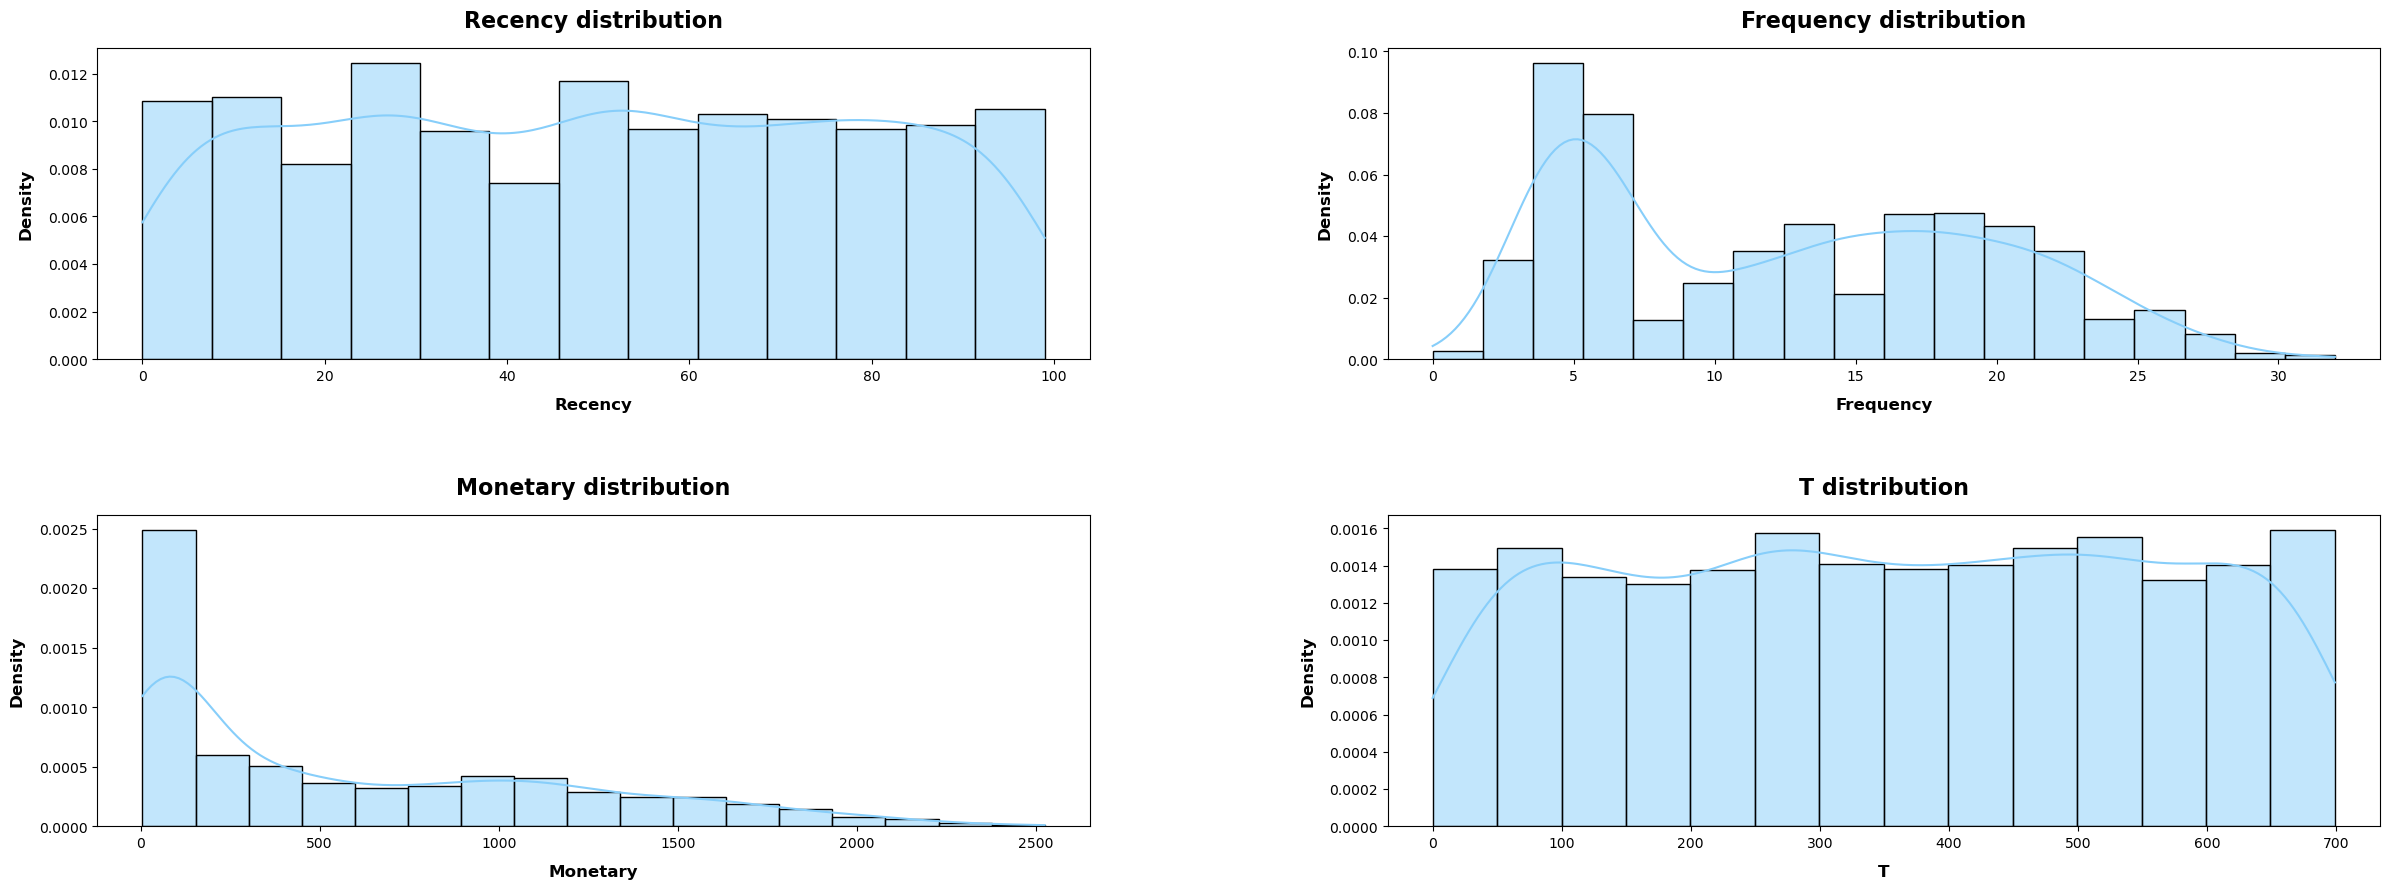

In [8]:
# plotting distriution of RFM-T features
fig, ax = plt.subplots(2, 2, figsize=(24, 9))
ax=ax.flatten()
for i, col in enumerate(['Recency', 'Frequency', 'Monetary', 'T']):
    sns.histplot(data=customer_df, x=col, stat='density', kde=True, color='lightskyblue', ax=ax[i])
    ax[i].set_title(f"{col} distribution", fontsize=16, fontweight='bold', y=1.04)
    ax[i].set_xlabel(f"{col}", fontsize=12, fontweight='bold', labelpad=10)
    ax[i].set_ylabel('Density', fontsize=12, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


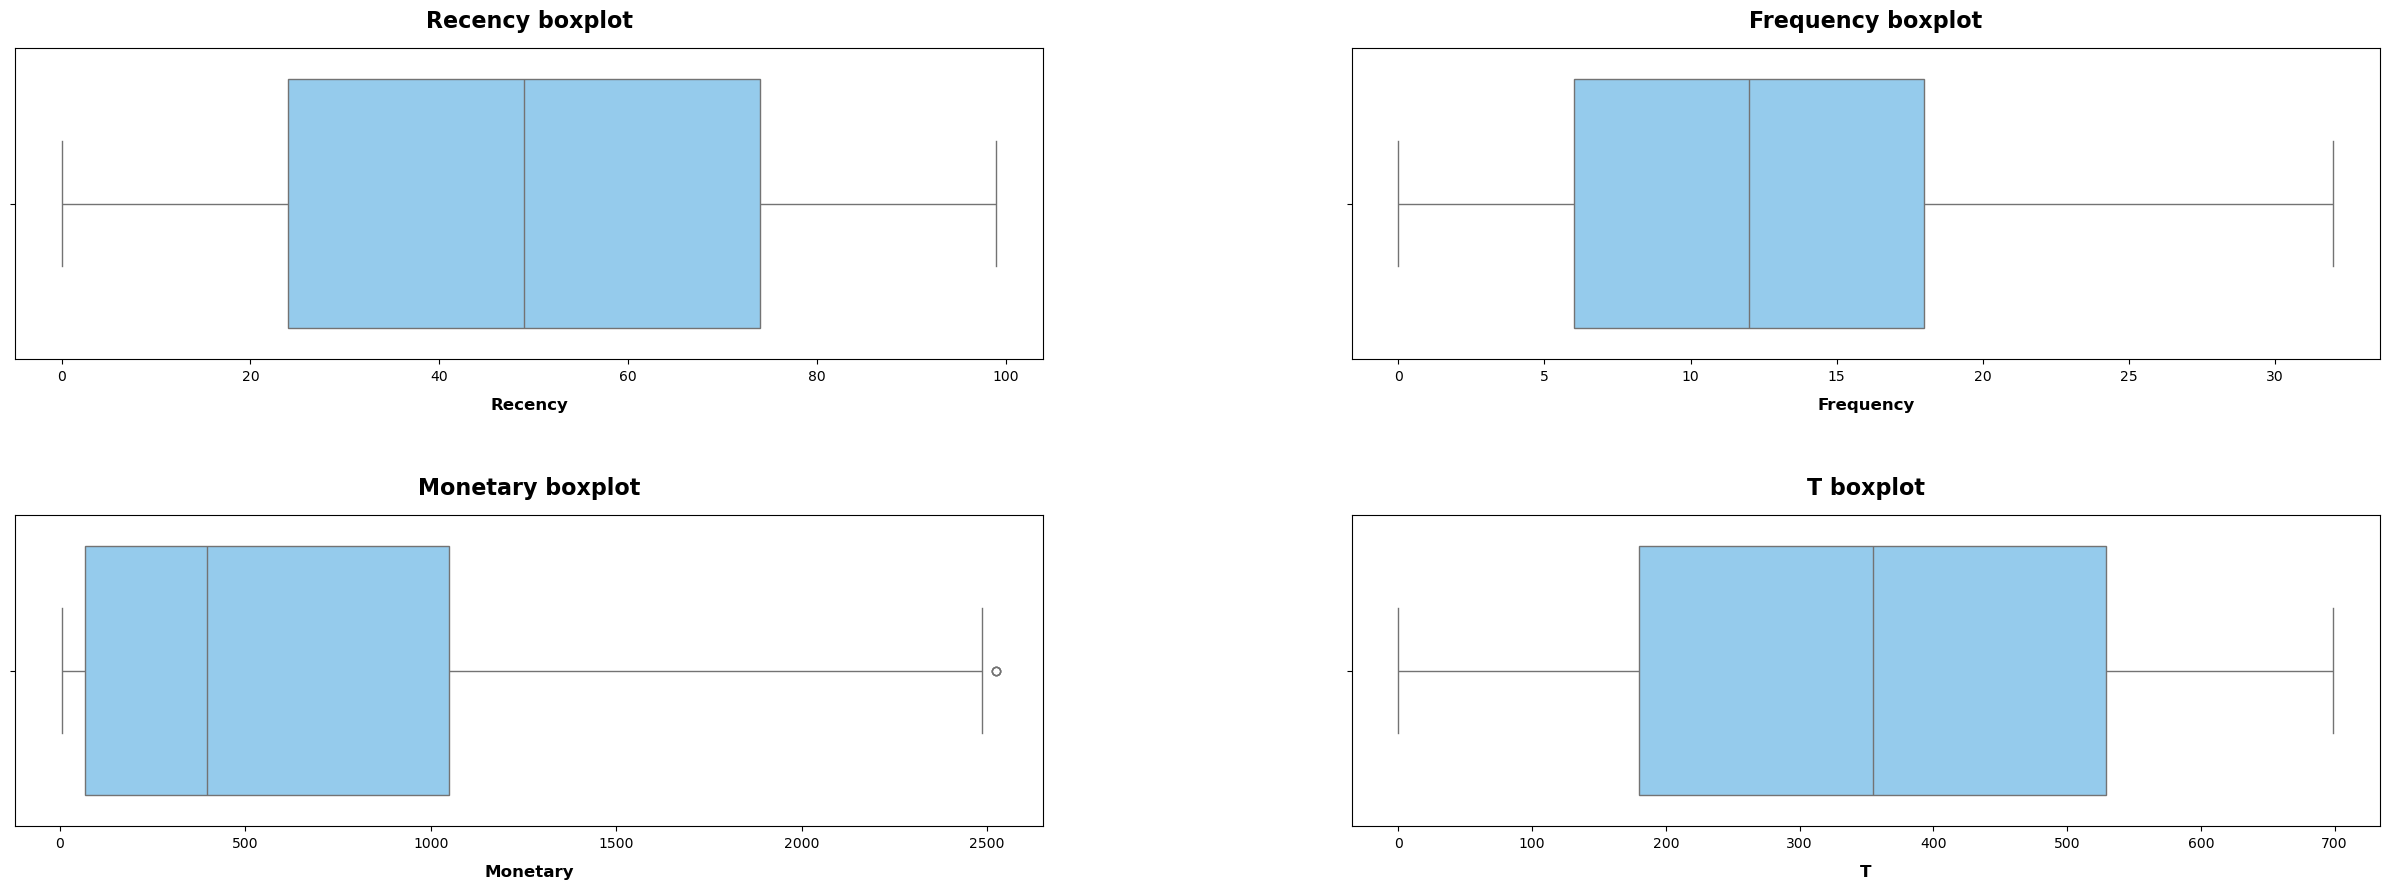

In [9]:
# plotting distriution of RFM-T features
fig, ax = plt.subplots(2, 2, figsize=(24, 9))
ax=ax.flatten()
for i, col in enumerate(['Recency', 'Frequency', 'Monetary', 'T']):
    sns.boxplot(data=customer_df, x=col, color='lightskyblue', ax=ax[i])
    ax[i].set_title(f"{col} boxplot", fontsize=16, fontweight='bold', y=1.04)
    ax[i].set_xlabel(f"{col}", fontsize=12, fontweight='bold', labelpad=10)
    #ax[i].set_ylabel('Density', fontsize=12, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


In [10]:
rfm_df.describe()

,ID,Recency,Frequency,Monetary,T
count,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000
mean,5588.462511,49.032520,12.565041,607.547425,353.486902
std,3248.656750,28.953612,7.202705,602.967666,202.522900
min,0.000000,0.000000,0.000000,5.000000,0.000000
25%,2817.750000,24.000000,6.000000,69.000000,180.000000
50%,5458.500000,49.000000,12.000000,397.000000,355.000000
75%,8419.500000,74.000000,18.000000,1048.000000,529.000000
max,11191.000000,99.000000,32.000000,2525.000000,699.000000


In [11]:
#checking for the values containing zero.

print(f"Total Number of Frequency with 0 : {len(rfm_df[rfm_df["Frequency"] == 0])}")
print(f"Total Number of Recency with 0 : {len(rfm_df[rfm_df["Recency"] == 0])}")
print(f"Total Number of Monetary Value with 0 : {len(rfm_df[rfm_df["Monetary"] == 0])}")


Total Number of Frequency with 0 : 6
Total Number of Recency with 0 : 28
Total Number of Monetary Value with 0 : 0


In this project, CLV is predicted at the customer level rather than at the cohort or aggregate level. This approach allows us to capture individual customer behavior for more personalized insights.



#### **3. Probablistic Models**

- **Beta Geo - Negative Binomial Distribution**

__NOTE__ : Make sure your dataset only includes **repeat customers (Frequency > 1)** and that the BG/NBD assumptions hold **(Recency ≤ Tenure)**, you should filter accordingly before fitting the model.


- Low frequency : The customer has made only a few purchases.

- High frequency : The customer has made many purchases.

- Low recency : Their last purchase was a long time ago (they haven't bought recently).

- High recency : Their last purchase was very recent.

**Insights:**

**Bottom-right: High frequency + High recency**
Example: 30 purchases, last purchase at 600+ days  
-> These are __best customers__. They buy often and recently, so they are highly engaged and loyal.
- **Business action:** Reward them with loyalty programs, exclusive offers, or VIP treatment to retain them.

**Top-right: High frequency + Low recency**  
-> Customers who used to buy a lot but haven't purchased in a long time. They may have **churned**.
- **Business action**: Run win-back campaigns (personalized emails, discounts, reactivation offers) to bring them back.

**Middle zone: Moderate frequency + Moderate recency**  
Example: around (15, 300)  
-> Customers who buy occasionally and haven't been seen recently. They might still be active, just between purchases.
- **Business action**: Nudge them with reminders, seasonal promotions, or product recommendations to encourage another purchase.

**Top-left: Low frequency + Low recency**  
-> Customers who bought once or very rarely, long ago. Least likely to return.
- **Business action**: Minimal investment; consider excluding them from expensive campaigns, but keep them in low-cost channels.


**Key Findings :**

- **High recency (recent purchase)** -> Probability alive is close to 1.0.
    - These customers are almost surely `alive` because the model assumes that if they bought recently, they are still active.

- **High frequency + Low recency (long time since last purchase) → Probability alive drops sharply.**

Surprisingly, the more they bought in the past, the more likely the model assumes they've dropped out if they suddenly stop. This is because a loyal customer's absence is a stronger signal of churn than a casual buyer's absence.


__Key takeaway__

- **Recency dominates**: recent activity is the strongest predictor of being alive.

- **Frequency amplifies churn signals**: if a heavy buyer stops, it's more alarming than if a light buyer stops.


This chart compares actual customer transaction frequencies with those predicted by the BG/NBD model during the calibration period.

**Interpretation**

- The x-axis shows how many repeat transactions customers made (from 0 to 8).

- The y-axis shows how many customers fall into each transaction count.

- Blue bars (Actual) represent real observed data.

- Orange bars (Model) represent simulated data generated using the fitted model's parameters.

**Insights**

- For low-frequency customers (0–2 transactions), the model overestimates compared to actual data — it predicts more customers with few purchases than observed.

- For mid-range frequencies (3–6 transactions), the model's predictions are closer to reality, showing good calibration.

- For high-frequency customers (7–8 transactions), the model underestimates — fewer customers are predicted than actually observed.

**What This Means**

- The model captures general purchasing behavior but struggles slightly at the extremes — it's too optimistic for infrequent buyers and too conservative for heavy buyers.

- This comparison helps assess model correctness by showing how well simulated data matches real-world patterns.


In [15]:
from lifetimes import BetaGeoFitter, ParetoNBDFitter, ModifiedBetaGeoFitter
from scipy.stats import norm, gamma, beta
from lifetimes import GammaGammaFitter
from sklearn.metrics import mean_squared_error

df_rfm = rfm_df.copy()
# Assumptions of probablistic models
# Exclude one-time buyers
data = df_rfm[df_rfm['Frequency'] > 0].copy()

# Ensure Recency <= Tenure
rfm_data = data[data['Recency'] <= data['T']]


# Dictionary of probabilistic models
models = {
    "BG/NBD": BetaGeoFitter(penalizer_coef=0.001),
    "Pareto/NBD": ParetoNBDFitter(penalizer_coef=0.001),
    "MBG/NBD": ModifiedBetaGeoFitter(penalizer_coef=0.001)
}

# Train each model
model_dataframes = {}

for name, model in models.items():

    # Train model
    model.fit(
        rfm_data["Frequency"],
        rfm_data["Recency"],
        rfm_data["T"]
    )

    # Expected purchases for next 90 days (or 3 months)
    predictions = model.conditional_expected_number_of_purchases_up_to_time(
        3*30,
        rfm_data["Frequency"],
        rfm_data["Recency"],
        rfm_data["T"]
    )

    # Actual purchases for next 90 days (or 3 months)
    rfm_data['Actual_90'] = ((rfm_data['Frequency']/rfm_data['Recency'])*90)

    # Create separate dataframe
    temp_df = pd.DataFrame({
        "ID": rfm_data["ID"],
        "Actual_Purchases": rfm_data['Actual_90'],
        "Predicted_Purchases": predictions
    })

    model_dataframes[name] = temp_df    

    print(f"{name} trained successfully")

    

BG/NBD trained successfully
Pareto/NBD trained successfully
MBG/NBD trained successfully


In [16]:
results = []
for model_name, model_df in model_dataframes.items():
    model_df = model_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    mse = mean_squared_error(model_df["Actual_Purchases"], model_df["Predicted_Purchases"])
    rmse = np.sqrt(float(mse))
    avg_error = (model_df["Actual_Purchases"] - model_df["Predicted_Purchases"]).mean()

    results.append({
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'Average_Error': avg_error
    })

model_results_df = pd.DataFrame(results)
model_results_df.index = model_results_df['Model']
model_results_df.drop(columns=['Model'], inplace=True)
display(model_results_df.style.highlight_min(axis='index', color='lightgreen').format("{:.2f}"))


,MSE,RMSE,Average_Error
Model,,,
BG/NBD,31146.46,176.48,63.33
Pareto/NBD,31063.07,176.25,63.26
MBG/NBD,31143.99,176.48,63.31


**Overall, the models show similar performance. However, the Pareto/NBD model performs slightly better, as it has the lowest MSE and RMSE values. Will use Pareto/NBD + Gamma-Gamma model to compute CLTV.**


## **Pareto - Negative Binomial Distribution + Gamma Gamma Distribution Model**

In [17]:
best_model_name = model_results_df['MSE'].idxmin()
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("\nParameters:")
print(best_model.params_)


Best Model: Pareto/NBD

Parameters:
r          0.813285
alpha      0.866899
s          3.552561
beta     180.139278
dtype: float64


| Customer behavior | Distribution | Denoted by | Parameters |
|---|---|---|---|
| Purchase rate | Gamma distribution | λ | r, α |
| Dropout rate | Gamma distribution | μ | s, β |
| Individual purchase process | Poisson process | — | λ |
| Individual dropout process | Exponential distribution | — | μ |


$\lambda \sim \mathrm{Gamma}(r,\alpha)$

Simply means, **Gamma → captures heterogeneity in purchase rates; $\lambda$ denotes an individual customer's purchase rate.**



$\mu \sim \mathrm{Gamma}(s,\beta)$

Simply means, **Gamma → captures heterogeneity in dropout rates; $\mu$ denotes an individual customer's dropout rate.**


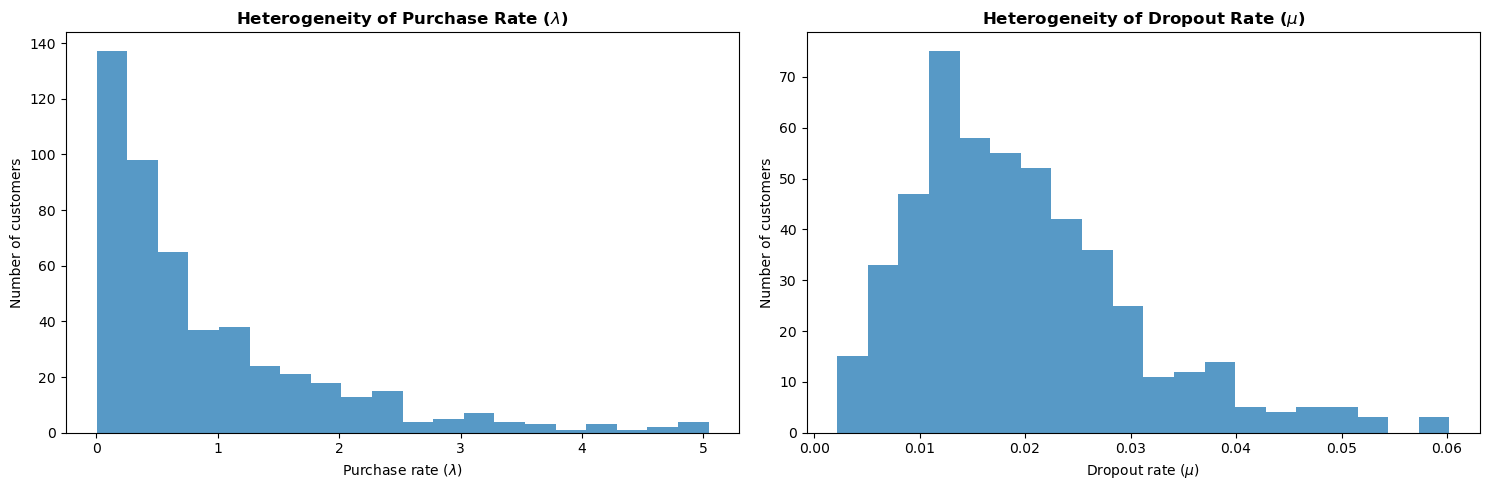

In [18]:
# Purchase-rate distribution
lambda_dist = gamma.rvs(
    a=best_model.params_['r'],
    scale=1 / best_model.params_['alpha'],
    size=500
)

# Dropout-rate distribution
mu_dist = gamma.rvs(
    a=best_model.params_['s'],
    scale=1 / best_model.params_['beta'],
    size=500
)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].set_title(r'Heterogeneity of Purchase Rate ($\lambda$)', fontsize=12, fontweight='bold')
ax[0].hist(lambda_dist, bins=20, alpha=0.75)
ax[0].set_xlabel(r'Purchase rate ($\lambda$)')
ax[0].set_ylabel('Number of customers')

ax[1].set_title(r'Heterogeneity of Dropout Rate ($\mu$)', fontsize=12, fontweight='bold')
ax[1].hist(mu_dist, bins=20, alpha=0.75)
ax[1].set_xlabel(r'Dropout rate ($\mu$)')
ax[1].set_ylabel('Number of customers')

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()


In [19]:
rfm_data.columns

Index(['ID', 'Recency', 'Frequency', 'Monetary', 'T', 'Actual_90'], dtype='object')

In [20]:
rfm_pareto = rfm_data[['ID', 'Frequency', 'Recency', 'Monetary', 'T']].merge(model_dataframes[best_model_name], on='ID', how='left')
display(rfm_pareto.head())


,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases
0,5524,22,58,1617,663,34.137931,7.513985e-25
1,2174,4,38,27,113,9.473684,3.554832e-02
2,4141,20,26,776,312,69.230769,5.789937e-22
3,6182,6,26,53,139,20.769231,1.114896e-04
4,5324,14,94,422,161,13.404255,1.160083e-02


**Visualizing frequency/recency matrix**

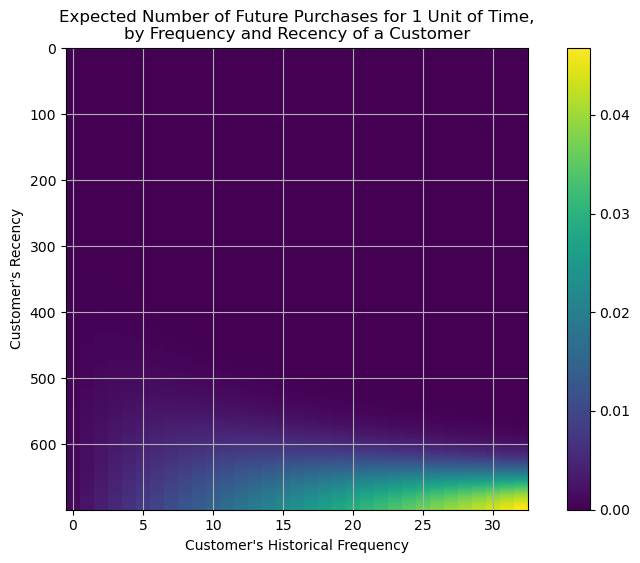

In [21]:

# plotting the frequency & recency matrix (computes the expected number of transactions a customer is to make in the next time period, given the R(age at last purchase) and F (the number of repeat transactions made))
plt.figure(figsize=(10, 6))
plot_frequency_recency_matrix(best_model)

plt.grid(axis='both')
plt.show()


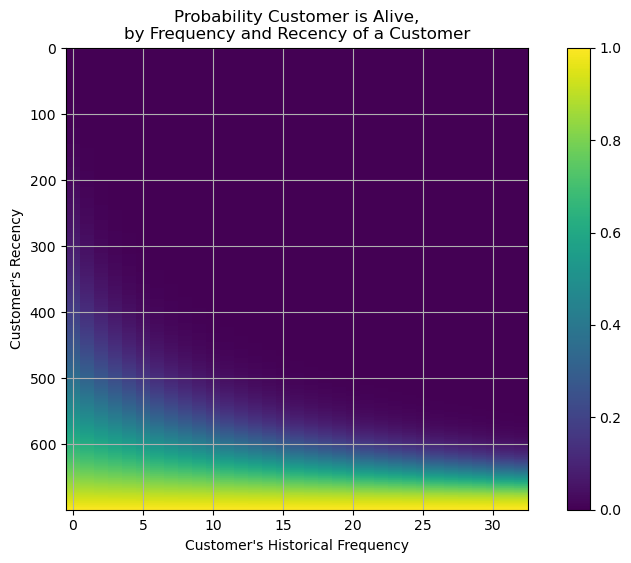

In [22]:
# plotting the churn matrix/ probability of active customer
plt.figure(figsize=(10, 6))
plot_probability_alive_matrix(best_model)

plt.grid(axis='both')
plt.show()


In [23]:
# Compute probablity of alive of eachh customer
rfm_pareto['p_alive'] = best_model.conditional_probability_alive(
    rfm_pareto['Frequency'],
    rfm_pareto['Recency'],
    rfm_pareto['T']
).round(4)

rfm_pareto['p_not_alive'] = 1 - best_model.conditional_probability_alive(
    rfm_pareto['Frequency'],
    rfm_pareto['Recency'],
    rfm_pareto['T']
).round(4)

display(rfm_pareto.head())


,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive
0,5524,22,58,1617,663,34.137931,7.513985e-25,0.0000,1.0000
1,2174,4,38,27,113,9.473684,3.554832e-02,0.0148,0.9852
2,4141,20,26,776,312,69.230769,5.789937e-22,0.0000,1.0000
3,6182,6,26,53,139,20.769231,1.114896e-04,0.0000,1.0000
4,5324,14,94,422,161,13.404255,1.160083e-02,0.0021,0.9979


**Ranking customers from best to worst**

We can rank our customers by who is expected to make the most purchases in the next period, down to those expected to make the least. The model uses each customer's purchase history to predict their future buying activity.

In [24]:
display_md("**Top 10 customers expected to make the most purchases in the next 3 months**")
display(rfm_pareto.sort_values(by = "Predicted_Purchases", ignore_index=True).round(4).tail(10))

display_md("**Insight:**")

display_md("This approach helps identify **high-value** customers who are most likely to buy again soon. Companies can then focus campaigns, loyalty programs, or personalized offers on these customers to maximize ROI.")


**Top 10 customers expected to make the most purchases in the next 3 months**

,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive
2055,5558,14,90,1685,90,14.0000,8.9716,1.0000,0.0000
2056,3830,15,59,459,66,22.8814,9.6697,0.7729,0.2271
2057,8566,3,10,9,14,27.0000,10.5948,0.8735,0.1265
2058,2963,20,56,1440,58,32.1429,17.6471,0.9574,0.0426
2059,7723,20,56,1440,58,32.1429,17.6471,0.9574,0.0426
2060,10767,20,40,1346,44,45.0000,19.5554,0.8312,0.1688
2061,6892,20,23,732,26,78.2609,30.6622,0.8123,0.1877
2062,2546,5,7,70,7,64.2857,34.2917,1.0000,0.0000
2063,9888,15,3,1091,4,450.0000,125.8045,0.8414,0.1586
2064,4399,15,3,1091,4,450.0000,125.8045,0.8414,0.1586


**Insight:**

This approach helps identify **high-value** customers who are most likely to buy again soon. Companies can then focus campaigns, loyalty programs, or personalized offers on these customers to maximize ROI.

**Model Evaluation**

To evaluate the accuracy of our model, the first step is to compare the actual customer data with artificial data generated using the parameters from our fitted model.


<Figure size 800x400 with 0 Axes>

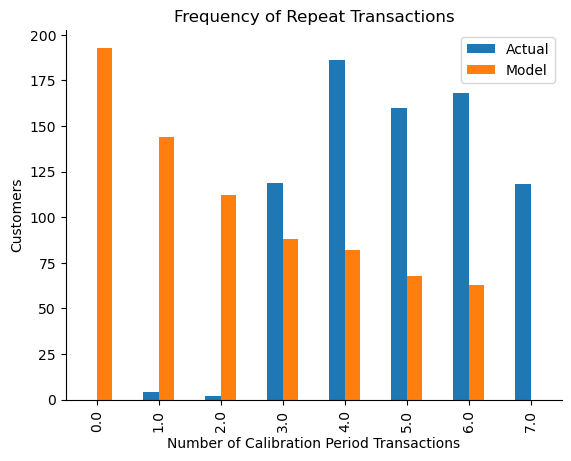

This chart compares actual customer purchase frequencies with those predicted by the best model during the calibration period.


**Insights**

Mid-range frequencies (3–6 transactions), the model's predictions are closer to reality, showing good calibration but low-frequeny(0-2) and high-frquency overestimates and underestimates respectively, compared with actual values.
CPU times: total: 6.48 s
Wall time: 9.63 s


In [25]:
%%time

plt.figure(figsize=(8, 4))
ax = plot_period_transactions(best_model)#, max_frequency=7)
sns.despine()
plt.show()

print("This chart compares actual customer purchase frequencies with those predicted by the best model during the calibration period.")
display_md("**Insights**")
print("Mid-range frequencies (3–6 transactions), the model's predictions are closer to reality, showing good calibration but low-frequeny(0-2) and high-frquency overestimates and underestimates respectively, compared with actual values.")


In [26]:
# Creating a function which can predict the future purchased value based on the specific period
def pnbd_model_prediction(t, id_):
    # select single row
    individual_row = rfm_pareto[rfm_pareto['ID']==id_].iloc[0]
    
    # predict the next purchase  in time t
    individual_pred = best_model.predict(t, individual_row['Frequency'], individual_row['Recency'], individual_row['T'])
    
    # Actual value
    actual_value = (individual_row['Frequency']/individual_row['Recency'])*t
    
    # Error
    error = actual_value - individual_pred

    print(f"Your Predicted Purchase : {individual_pred:.4f}")
    print(f"Your Actual Purchase : {actual_value:.4f}")
    print(f"Prediction Error : {error:.4f}")


# Apply on some customer id
print(pnbd_model_prediction(90, 5524))
print()
print("*"*40, end="\n\n")
print(pnbd_model_prediction(90, 2963))


Your Predicted Purchase : 0.0000
Your Actual Purchase : 34.1379
Prediction Error : 34.1379
None

****************************************

Your Predicted Purchase : 17.6471
Your Actual Purchase : 32.1429
Prediction Error : 14.4958
None


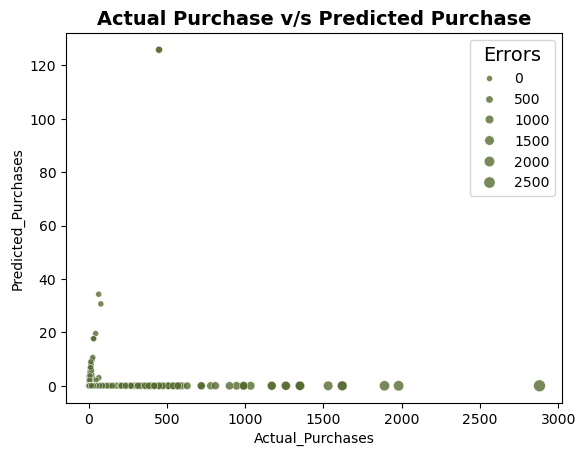

In [27]:
rfm_pnbd = rfm_pareto.replace([np.inf, -np.inf], np.nan).fillna(0)
# calculating the prediction error for the 30 days purchase prediction
error = rfm_pnbd["Actual_Purchases"] - rfm_pnbd["Predicted_Purchases"]

# Visualization
sns.scatterplot(rfm_pnbd, x= "Actual_Purchases", y= "Predicted_Purchases", size = error, color='darkolivegreen', alpha=0.8)
plt.title("Actual Purchase v/s Predicted Purchase", fontsize=14, fontweight='bold')
plt.legend(title='Errors', title_fontsize=14)
plt.show()


#### **Gamma Gamma Distribution Model**

In [91]:
rfm_ggd = rfm_pnbd[(rfm_pnbd['Frequency']>0) & (rfm_pnbd['Monetary'] > 0)]
display(rfm_ggd.head())
display_md(f'**Customers with atleast 1 repeat purchase** : {len(rfm_ggd)}')


,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive
0,5524,22,58,1617,663,34.137931,7.513985e-25,0.0000,1.0000
1,2174,4,38,27,113,9.473684,3.554832e-02,0.0148,0.9852
2,4141,20,26,776,312,69.230769,5.789937e-22,0.0000,1.0000
3,6182,6,26,53,139,20.769231,1.114896e-04,0.0000,1.0000
4,5324,14,94,422,161,13.404255,1.160083e-02,0.0021,0.9979


**Customers with atleast 1 repeat purchase** : 2065

In [92]:
## Compute Actual Average Profit Per Transaction 
rfm_ggd.loc[:,'Actual_Avg_Monetary'] = rfm_ggd['Monetary'] / rfm_ggd['Frequency']

## Compute Average Profit Per Transaction using Gamam-Gamma Approach
# model fits in average sales per transaction 
ggf_pareto = GammaGammaFitter(penalizer_coef = 0.01)
ggf_pareto.fit(rfm_ggd['Frequency'], rfm_ggd['Actual_Avg_Monetary'])
display_md("**Gamma-Gamma Model Parameters :**")
display(ggf_pareto.summary)

rfm_ggd['Predicted_Avg_Monetary'] = ggf_pareto.conditional_expected_average_profit(rfm_ggd['Frequency'],rfm_ggd['Actual_Avg_Monetary'])
display_md('**RFM Dataset :**')
display(rfm_ggd.head())


**Gamma-Gamma Model Parameters :**

,coef,se(coef),lower 95% bound,upper 95% bound
p,3.474162,0.098856,3.280403,3.667921
q,0.845742,0.022733,0.801186,0.890298
v,3.421026,0.100205,3.224625,3.617427


**RFM Dataset :**

,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive,Actual_Avg_Monetary,Predicted_Avg_Monetary
0,5524,22,58,1617,663,34.137931,7.513985e-25,0.0000,1.0000,73.500000,73.804457
1,2174,4,38,27,113,9.473684,3.554832e-02,0.0148,0.9852,6.750000,7.690625
2,4141,20,26,776,312,69.230769,5.789937e-22,0.0000,1.0000,38.800000,39.057763
3,6182,6,26,53,139,20.769231,1.114896e-04,0.0000,1.0000,8.833333,9.473611
4,5324,14,94,422,161,13.404255,1.160083e-02,0.0021,0.9979,30.142857,30.483897


Predicted Average Sales: 38.3707
Actual Average Sales: 37.8101
Difference: -0.5605
Mean Squared Error: 0.5408
Root Mean Squared Error: 0.7354


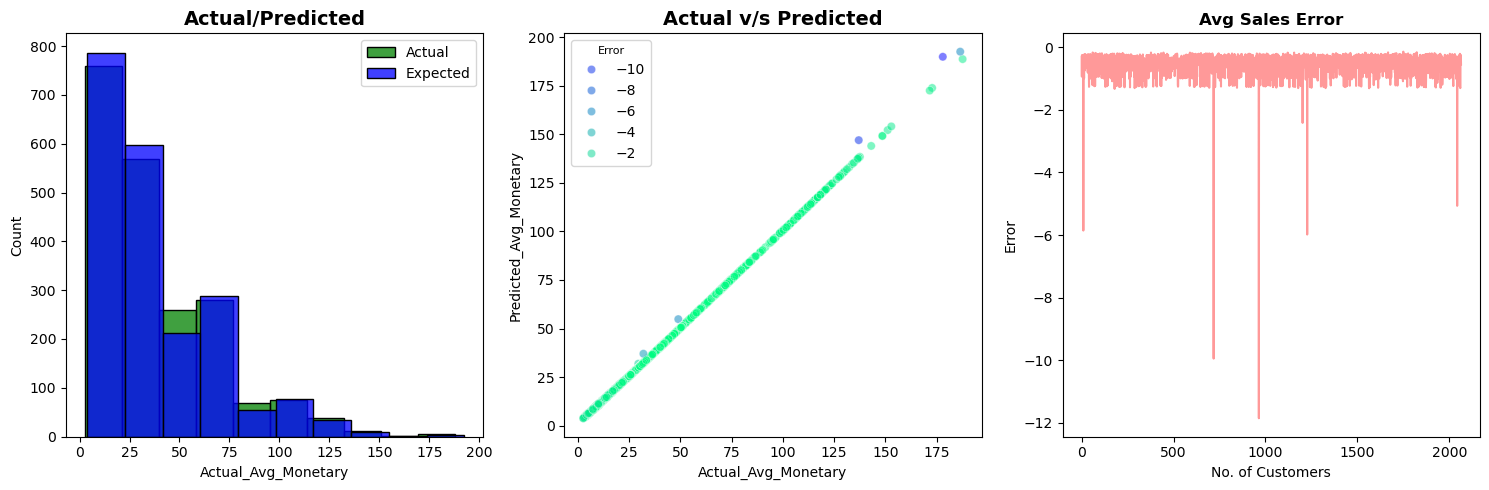

In [93]:
print(f"Predicted Average Sales: {rfm_ggd["Predicted_Avg_Monetary"].mean():.4f}")
print(f"Actual Average Sales: {rfm_ggd["Actual_Avg_Monetary"].mean():.4f}")
print(f"Difference: {(rfm_ggd["Actual_Avg_Monetary"].mean() - rfm_ggd["Predicted_Avg_Monetary"].mean()):.4f}")
print(f"Mean Squared Error: {(mean_squared_error(rfm_ggd["Actual_Avg_Monetary"], rfm_ggd["Predicted_Avg_Monetary"])):.4f}")
print(f"Root Mean Squared Error: {(sqrt(mean_squared_error(rfm_ggd["Actual_Avg_Monetary"], rfm_ggd["Predicted_Avg_Monetary"]))):.4f}")
      
# visualization
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(rfm_ggd["Actual_Avg_Monetary"], color = "g", bins=10, kde = False, ax = ax[0])
sns.histplot(rfm_ggd["Predicted_Avg_Monetary"], color = "b", bins=10, kde = False, ax=ax[0])
ax[0].set_title("Actual/Predicted", fontsize=14, fontweight='bold')
ax[0].legend(["Actual", "Expected"])

error = (rfm_ggd["Actual_Avg_Monetary"]-rfm_ggd["Predicted_Avg_Monetary"])

sns.scatterplot(data=rfm_ggd, x="Actual_Avg_Monetary", y="Predicted_Avg_Monetary", alpha = 0.5, hue = error, palette = "winter",ax=ax[1])
ax[1].set_title("Actual v/s Predicted", fontsize=14, fontweight='bold')
ax[1].legend(title='Error', title_fontsize=8)

ax[2].plot(error, color = 'r', alpha = 0.4)
ax[2].set_title("Avg Sales Error", fontsize=12, fontweight='bold')
ax[2].set_xlabel('No. of Customers')
ax[2].set_ylabel('Error')

plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()

## **CLTV using Gamma-Gamma Model + Pareto/NBD**

In [94]:
# Actual CLTV
# Manual predict clv = Predicted no. of transactions * Expected avg sales * profit_margin to compute profit from each transaction
profit_margin = 0.05
rfm_ggd['Actual_cltv'] = (rfm_ggd['Predicted_Purchases'] * rfm_ggd['Predicted_Avg_Monetary'] * profit_margin).map(lambda x: f"{x:.2f}").astype(float)


# The customers' lifetime values expected to in the next 3 months
rfm_ggd['Predicted_cltv'] = ggf_pareto.customer_lifetime_value(
    best_model,  # the model to use to predict the number of future transactions
    rfm_ggd['Frequency'],rfm_ggd['Recency'],rfm_ggd['T'],rfm_ggd['Actual_Avg_Monetary'],
    time=3,  #3 months
    freq="M",  #frequency information of T. In this case we set week by using 'D'
    discount_rate=0.01).map(lambda x: f"{x:.2f}").astype(float)

display(rfm_ggd.head())


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive,Actual_Avg_Monetary,Predicted_Avg_Monetary,Actual_cltv,Predicted_cltv
0,5524,22,58,1617,663,34.137931,7.513985e-25,0.0000,1.0000,73.500000,73.804457,0.00,0.00
1,2174,4,38,27,113,9.473684,3.554832e-02,0.0148,0.9852,6.750000,7.690625,0.01,0.01
2,4141,20,26,776,312,69.230769,5.789937e-22,0.0000,1.0000,38.800000,39.057763,0.00,0.00
3,6182,6,26,53,139,20.769231,1.114896e-04,0.0000,1.0000,8.833333,9.473611,0.00,0.00
4,5324,14,94,422,161,13.404255,1.160083e-02,0.0021,0.9979,30.142857,30.483897,0.02,0.02


In [95]:
# Top 5 customers with high CLV
display_md("**Top 5 customers with high CLV**")
display(rfm_ggd[["ID", "Predicted_cltv"]].sort_values(by = "Predicted_cltv", ascending = False).head(5))
     

**Top 5 customers with high CLV**

,ID,Predicted_cltv
1343,4399,571.84
956,9888,571.84
638,10767,74.91
700,7723,70.43
1280,2963,70.43


,Actual,Predicted,Error
0,2509.137931,5.545656e-23,2509.137931
1,63.947368,2.733888e-01,63.673980
2,2686.153846,2.261420e-20,2686.153846
3,183.461538,1.056210e-03,183.460482
4,404.042553,3.536384e-01,403.688915


Average Error: 3172.393050243987
Mean Squared Error: 125521251.57040478
Root Mean Squared Error: 11203.62671505994


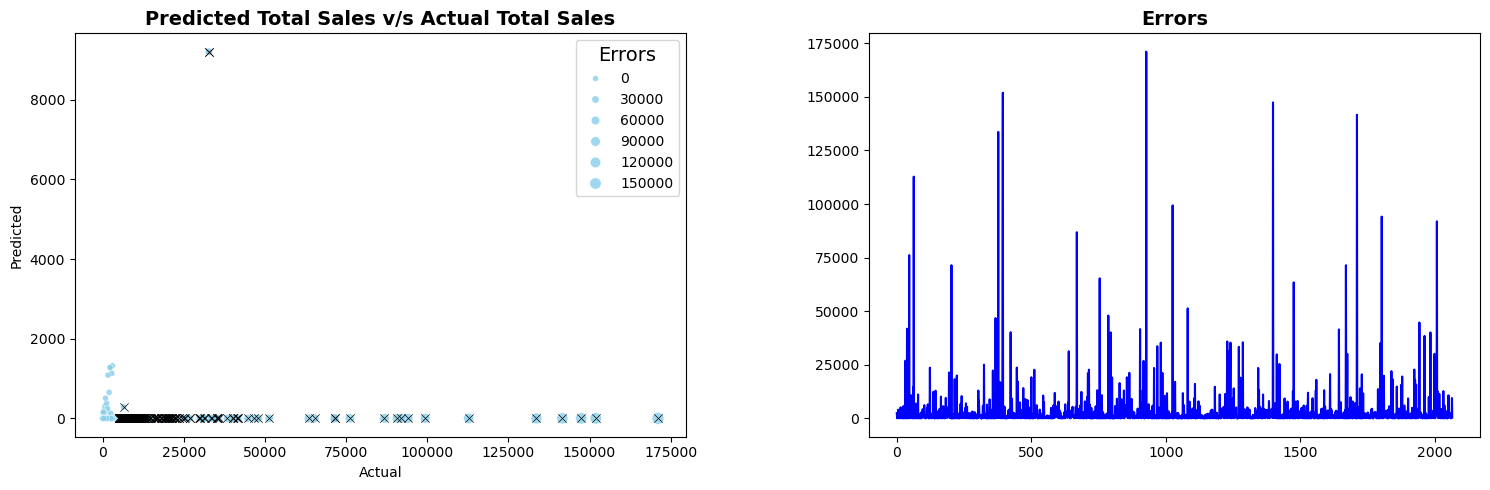

In [96]:
# actual spend in 3 months
actual =  rfm_ggd['Actual_Avg_Monetary'] * rfm_ggd['Actual_Purchases']

# predicted spend in 3 months
predicted = rfm_ggd['Predicted_Purchases'] * rfm_ggd['Predicted_Avg_Monetary']

# Error
error = actual - predicted

# create dataframe
result_df = pd.DataFrame([actual, predicted, error], index = ["Actual", "Predicted", "Error"]).T
display(result_df.head())

print(f"Average Error: {result_df['Error'].mean()}")
print(f"Mean Squared Error: {mean_squared_error(result_df['Actual'], result_df['Predicted'])}")
print(f"Root Mean Squared Error: {sqrt(mean_squared_error(result_df['Actual'], result_df['Predicted']))}")

#Predicted v/s Actual
fig, ax = plt.subplots(1, 2, figsize=(15,5))

sns.scatterplot(data=result_df, x="Actual", y="Predicted", size = "Error", color = "skyblue", alpha = 0.8, marker = 'o', ax=ax[0])
sns.scatterplot(x = result_df[result_df["Error"] > 5000]["Actual"], y=result_df[result_df["Error"] > 5000]["Predicted"], data=result_df, color = "k", marker = "x", ax=ax[0])
ax[0].set_title("Predicted Total Sales v/s Actual Total Sales", fontsize=14, fontweight='bold')
ax[0].legend(title='Errors', title_fontsize=14)

ax[1].plot(result_df["Error"], color = "b")
ax[1].set_title("Errors", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()



In [97]:
print(rfm_ggd['Predicted_cltv'].value_counts().nlargest(2))
print("\n"+"*"*20+ "*"*20, end="\n")
print(rfm_ggd['Actual_cltv'].value_counts().nlargest(2))


Predicted_cltv
0.00    1849
0.01      32
Name: count, dtype: int64

****************************************
Actual_cltv
0.00    1847
0.01      35
Name: count, dtype: int64


Since most of the CLV scores are zero, we categorize customers into two groups:

- **Profitable** (those with predicted CLTV greater than zero)
- **Non-Profitable** (those with predicted CLTV equal to zero).


In [98]:
rfm_ggd['CLTV_label'] = rfm_ggd['Predicted_cltv'] > 0
rfm_ggd['CLTV_label'] = rfm_ggd['CLTV_label'].map({True: 'Profitable', False: 'Non-profitable'})
display(rfm_ggd.head())


,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive,Actual_Avg_Monetary,Predicted_Avg_Monetary,Actual_cltv,Predicted_cltv,CLTV_label
0,5524,22,58,1617,663,34.137931,7.513985e-25,0.0000,1.0000,73.500000,73.804457,0.00,0.00,Non-profitable
1,2174,4,38,27,113,9.473684,3.554832e-02,0.0148,0.9852,6.750000,7.690625,0.01,0.01,Profitable
2,4141,20,26,776,312,69.230769,5.789937e-22,0.0000,1.0000,38.800000,39.057763,0.00,0.00,Non-profitable
3,6182,6,26,53,139,20.769231,1.114896e-04,0.0000,1.0000,8.833333,9.473611,0.00,0.00,Non-profitable
4,5324,14,94,422,161,13.404255,1.160083e-02,0.0021,0.9979,30.142857,30.483897,0.02,0.02,Profitable


In [99]:
# saving the results to a CSV file
rfm_ggd.to_csv(parent_path.joinpath("data", "processed", "cltv_df.csv"), index=False)
print("="*20, "CLTV dataset saved successfully.", "="*20)


==================== CLTV dataset saved successfully. ====================


In [100]:
# Compute tenure in days for further requirements
customer_seg_df['T'] = (
    (
        customer_seg_df['Dt_Customer'].max() - customer_seg_df['Dt_Customer']
    ).dt.days
    
)

# satisfy assumptions of probablistic models
customer_seg_df = customer_seg_df.query("Frequency > 0").query("Recency <= T").copy()

# Create CLV label for customer segmentation dataframe as well
customer_seg_df['CLTV_label'] = rfm_ggd['Predicted_cltv'] > 0
customer_seg_df['CLTV_label'] = customer_seg_df['CLTV_label'].map({True: 'Profitable', False: 'Non-profitable'})
display(customer_seg_df.head())


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Children,Day,Month,Quarter,Year,Tenure,Cluster,Recency,Monetary,Frequency,R,F,M,RFM_Score,Segment,T,CLTV_label
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,0,0,4,9,3,2012,28,1,58,73.500000,22,3,5,5,355,Loyal Customers,659,Non-profitable
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,1,2,8,3,1,2014,9,0,38,6.750000,4,4,1,1,411,Promising,109,Profitable
2,4141,1965,Graduation,Partner,71613.0,0,0,2013-08-21,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,50,0,0,21,8,3,2013,16,2,26,38.800000,20,4,4,4,444,Loyal Customers,308,Non-profitable
3,6182,1984,Graduation,Partner,26646.0,1,0,2014-02-10,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,31,1,1,10,2,1,2014,10,0,26,8.833333,6,4,2,1,421,Potential Loyalists,135,Non-profitable
4,5324,1981,PhD,Partner,58293.0,1,0,2014-01-19,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,34,1,1,19,1,1,2014,11,2,94,30.142857,14,1,3,3,133,At risk,157,Profitable


In [101]:
# saving the customer segmentation dataset with CLTV label to a CSV file
customer_seg_df.to_csv(parent_path.joinpath("data", "processed", "customer_segmentation_cltv.csv"), index=False)
print("="*20, "Customer Segmentation dataset with CLTV label saved successfully.", "="*20)


==================== Customer Segmentation dataset with CLTV label saved successfully. ====================


## **CUSTOMER SEGMENTATION USING PREDICTED CLTV**

We have calculated the Customer Lifetime Value (CLV) and shared it with the marketing team. Now, the marketing team wants to identify the **most profitable customer segments** so they can target them with more effective and optimized marketing campaigns.

Our objective is to provide the requested insights to the marketing team. To achieve this, we will perform **customer clustering based on the predicted metrics** to identify meaningful and profitable customer segments.


In [126]:
display(rfm_ggd.head())


,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive,Actual_Avg_Monetary,Predicted_Avg_Monetary,Actual_cltv,Predicted_cltv,CLTV_label
0,5524,22,58,1617,663,34.137931,7.513985e-25,0.0000,1.0000,73.500000,73.804457,0.00,0.00,Non-profitable
1,2174,4,38,27,113,9.473684,3.554832e-02,0.0148,0.9852,6.750000,7.690625,0.01,0.01,Profitable
2,4141,20,26,776,312,69.230769,5.789937e-22,0.0000,1.0000,38.800000,39.057763,0.00,0.00,Non-profitable
3,6182,6,26,53,139,20.769231,1.114896e-04,0.0000,1.0000,8.833333,9.473611,0.00,0.00,Non-profitable
4,5324,14,94,422,161,13.404255,1.160083e-02,0.0021,0.9979,30.142857,30.483897,0.02,0.02,Profitable


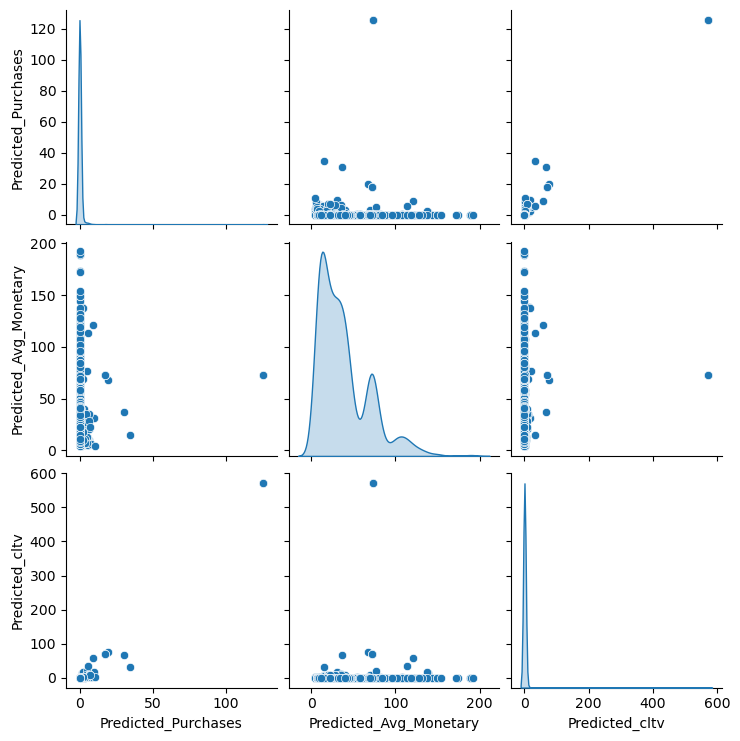

In [127]:
# Selected columns for clustering
cols = ['Predicted_Purchases', 'Predicted_Avg_Monetary', 'Predicted_cltv']
sns.pairplot(rfm_ggd[cols], diag_kind='kde')
plt.show()


In [128]:
new_df = rfm_ggd[cols].copy()


no_cluster,wcss,explained_variance(%),pct_explained_variance
1,2583844.120000,-0.000000,0.000000
2,1231408.670000,0.520000,0.520000
3,1020336.300000,0.610000,0.080000
4,339288.890000,0.870000,0.260000
5,155082.160000,0.940000,0.070000
6,125232.350000,0.950000,0.010000
7,91283.640000,0.960000,0.010000
8,79731.320000,0.970000,0.000000
9,58692.280000,0.980000,0.010000
10,51595.560000,0.980000,0.000000


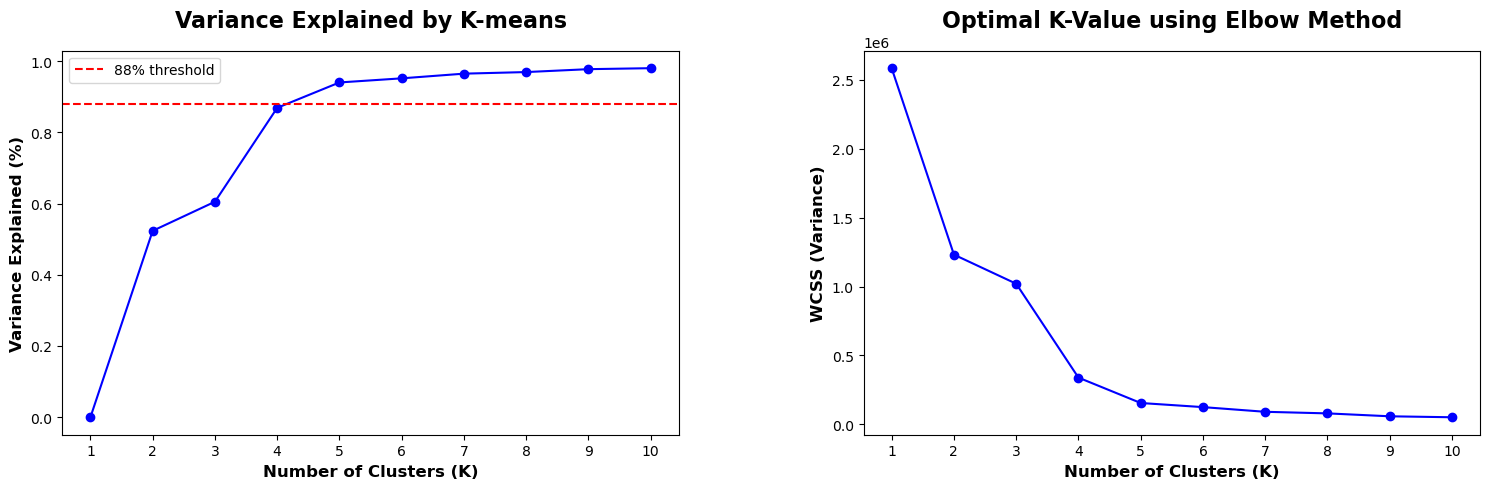

In [129]:
from sklearn.cluster import KMeans
#  Total variance = sum of squared distances from mean
overall_mean = np.mean(np.array(new_df), axis=0)
total_variance = np.sum((np.array(new_df) - overall_mean)**2)

# KMeans Clustering with elbow method
wcss = []                           # Within-Cluster-Sum-of-Squares (WCSS)
explained_variance = []
n_cluster = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(new_df)
    inertias = kmeans.inertia_
    wcss.append(inertias)
    bcss = total_variance - inertias      # between-cluster sum of squares
    explained_variance.append(bcss / total_variance)
    n_cluster.append(k)

# create dataframe
cluster_df = pd.DataFrame([], columns=['no_cluster', 'wcss', 'explained_variance(%)'])
cluster_df['no_cluster'] = n_cluster
cluster_df['wcss'] = wcss
cluster_df['explained_variance(%)'] = explained_variance
cluster_df['explained_variance(%)'] = cluster_df['explained_variance(%)'].map(lambda x: f'{x:.4f}').astype('float')
cluster_df = cluster_df.assign(pct_explained_variance=cluster_df['explained_variance(%)'].diff())
display(cluster_df.fillna(0).round(2).style.hide(axis='index').set_caption("KMeans Clustering with Elbow Method"))

# plot 
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
# plot no. of clusters with variance explained
ax[0].plot(range(1, 11), explained_variance, 'bo-')
ax[0].set_xticks(range(1, 11))
ax[0].axhline(y=0.88, color='r', ls='--', label='88% threshold')
ax[0].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
ax[0].set_title('Variance Explained by K-means', fontsize=16, fontweight='bold', y=1.04)
ax[0].legend()

# plot no. of clusters with elbow method
ax[1].plot(range(1, 11), wcss, 'bo-')
ax[1].set_xticks(range(1, 11))
ax[1].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('WCSS (Variance)', fontsize=12, fontweight='bold')
ax[1].set_title('Optimal K-Value using Elbow Method', fontsize=16, fontweight='bold', y=1.04)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


In [130]:
# will choose the smallest k that explains at least 94% of the variance, which is k=4

kmeans_clts = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans_y = kmeans_clts.fit_predict(new_df)

# Add cluster labels to the DataFrame
kmeans_cluster_df = pd.DataFrame(new_df).copy()
kmeans_cluster_df.loc[:,'Cluster'] = kmeans_y
display(kmeans_cluster_df.head())


,Predicted_Purchases,Predicted_Avg_Monetary,Predicted_cltv,Cluster
0,7.513985e-25,73.804457,0.00,1
1,3.554832e-02,7.690625,0.01,2
2,5.789937e-22,39.057763,0.00,0
3,1.114896e-04,9.473611,0.00,2
4,1.160083e-02,30.483897,0.02,0


In [131]:
# centeroid of each cluster for each features
print(f"Cluster centers:\n{kmeans_clts.cluster_centers_}", end='\n\n')

# cluster label
print(f"Cluster labels: {kmeans_clts.labels_}")


Cluster centers:
[[1.08732638e-01 3.79610643e+01 2.05898161e-01]
 [1.83687970e-01 8.55260195e+01 8.24741379e-01]
 [2.73683783e-01 1.40880220e+01 1.79697309e-01]
 [1.25804468e+02 7.31780161e+01 5.71840000e+02]]

Cluster labels: [1 2 0 ... 1 0 2]


In [132]:
cluster_summary = kmeans_cluster_df.groupby('Cluster').mean()
cluster_summary['n_customers'] = kmeans_cluster_df.groupby('Cluster').size()
cluster_summary['percentage_customers'] = ((cluster_summary['n_customers']/cluster_summary['n_customers'].sum())*100).map(lambda x: f'{x:.1f}%')
display(cluster_summary)#.sort_values(by='Predicted_cltv', ascending=False).style.format("{:.2f}").set_caption("Cluster Summary"))


,Predicted_Purchases,Predicted_Avg_Monetary,Predicted_cltv,n_customers,percentage_customers
Cluster,,,,,
0,0.108733,37.961064,0.205898,707,34.2%
1,0.183688,85.526020,0.824741,464,22.5%
2,0.273684,14.088022,0.179697,892,43.2%
3,125.804468,73.178016,571.840000,2,0.1%


**Will name the cluster based on below table**

| Cluster | Characteristics | Suggested Name |
|---:|---|---|
| 0 | Low CLV, low purchases | Low-Value Customers |
| 1 | high CLV, medium purchases | High-Value Customers |
| 2 | medium CLV, medium purchases | Moderate-value Customers |
| 3 | Very high CLV, high purchases | VIP Customers |


In [133]:
cluster_labels = {
    3: "VIP",
    1: "High-Value",
    2: "Moderate-Value",
    0: "Low-Value"
}

kmeans_cluster_df["Customer_Segment"] = kmeans_cluster_df["Cluster"].map(cluster_labels)



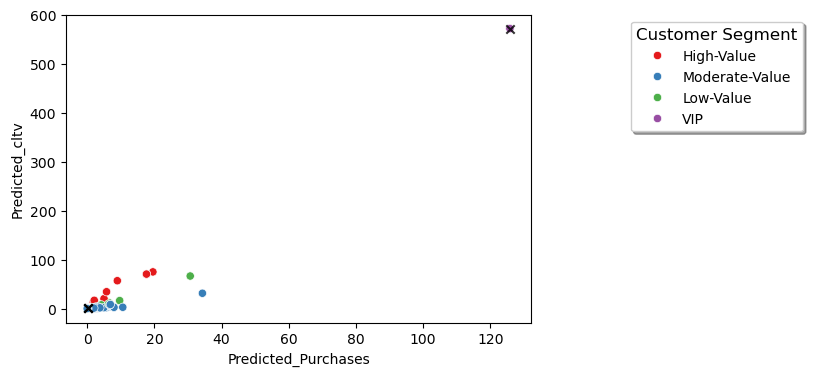

In [134]:
centers = kmeans_clts.cluster_centers_
# Visualization
plt.figure(figsize=(6, 4))
sns.scatterplot(x = "Predicted_Purchases", y = "Predicted_cltv", hue = "Customer_Segment", palette = "Set1", data = kmeans_cluster_df)
plt.scatter(centers[:, 0], centers[:, 2], marker = "x", color = "k", alpha = 0.8)
plt.legend(title="Customer Segment", title_fontsize=12, fontsize=10, loc='upper right', bbox_to_anchor=(1.6, 1), shadow=True)#, ncol=2)
plt.show()
     

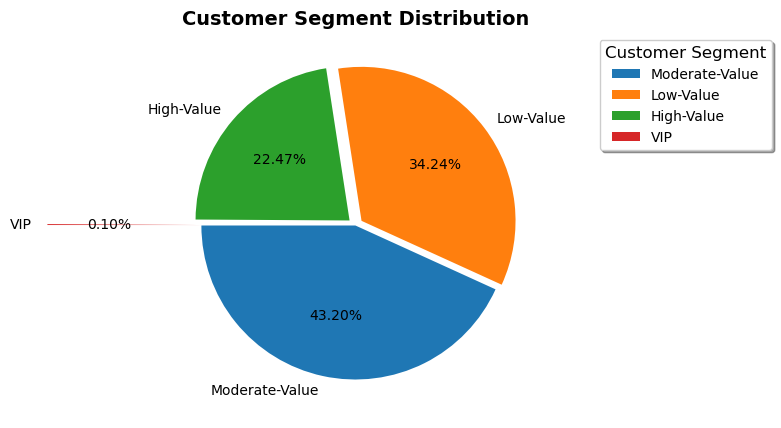

In [150]:
plt.figure(figsize=(5,5))
plt.pie(kmeans_cluster_df["Customer_Segment"].value_counts(), labels = kmeans_cluster_df["Customer_Segment"].value_counts().index, startangle = 180, explode = [0.0,0.05,0.05,1], autopct = "%1.2f%%")
plt.title("Customer Segment Distribution", fontsize=14, fontweight='bold')
plt.legend(loc='upper right', title="Customer Segment", title_fontsize=12, fontsize=10, bbox_to_anchor=(1.6, 1), shadow=True)
plt.show()


In [136]:
rfm_gg = rfm_ggd.merge(kmeans_cluster_df[['Cluster', 'Customer_Segment']], left_index=True, right_index=True, how='left')
display(rfm_gg.head())

,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive,Actual_Avg_Monetary,Predicted_Avg_Monetary,Actual_cltv,Predicted_cltv,CLTV_label,Cluster,Customer_Segment
0,5524,22,58,1617,663,34.137931,7.513985e-25,0.0000,1.0000,73.500000,73.804457,0.00,0.00,Non-profitable,1,High-Value
1,2174,4,38,27,113,9.473684,3.554832e-02,0.0148,0.9852,6.750000,7.690625,0.01,0.01,Profitable,2,Moderate-Value
2,4141,20,26,776,312,69.230769,5.789937e-22,0.0000,1.0000,38.800000,39.057763,0.00,0.00,Non-profitable,0,Low-Value
3,6182,6,26,53,139,20.769231,1.114896e-04,0.0000,1.0000,8.833333,9.473611,0.00,0.00,Non-profitable,2,Moderate-Value
4,5324,14,94,422,161,13.404255,1.160083e-02,0.0021,0.9979,30.142857,30.483897,0.02,0.02,Profitable,0,Low-Value


In [137]:
# saving the customer segmentation dataset with CLTV label to a CSV file
rfm_gg.to_csv(data_path.joinpath("ParetoNBD_GammaGamma_CLTV_Analysis.csv"), index=False)
print("="*20, "Customer Segmentation dataset with CLTV label saved successfully.", "="*20)


==================== Customer Segmentation dataset with CLTV label saved successfully. ====================


In [138]:
# Grouping by Customer Segment and calculating mean values for key metrics
result_df = rfm_gg.groupby('Customer_Segment').agg({
    'Predicted_Purchases': 'mean',
    'Predicted_Avg_Monetary': 'mean',
    'Predicted_cltv': 'mean',
    'p_alive': 'mean'})
result_df 


,Predicted_Purchases,Predicted_Avg_Monetary,Predicted_cltv,p_alive
Customer_Segment,,,,
High-Value,0.183688,85.526020,0.824741,0.012821
Low-Value,0.108733,37.961064,0.205898,0.008735
Moderate-Value,0.273684,14.088022,0.179697,0.050843
VIP,125.804468,73.178016,571.840000,0.841400


**1. who are the most valuable customers?**

In [153]:
display(result_df['Predicted_cltv'].sort_values(ascending=False))


Customer_Segment
VIP               571.840000
High-Value          0.824741
Low-Value           0.205898
Moderate-Value      0.179697
Name: Predicted_cltv, dtype: float64

**2. Who is likely to remain active?**

In [140]:
display(result_df['p_alive'].sort_values(ascending=False))


Customer_Segment
VIP               0.841400
Moderate-Value    0.050843
High-Value        0.012821
Low-Value         0.008735
Name: p_alive, dtype: float64

**3. Who is likely to purchase again?**

In [141]:
display(result_df['Predicted_Purchases'].sort_values(ascending=False))


Customer_Segment
VIP               125.804468
Moderate-Value      0.273684
High-Value          0.183688
Low-Value           0.108733
Name: Predicted_Purchases, dtype: float64

**4. Where should we spend our marketing budget?**

| Segment | Recommended Strategy | Marketing Priority |
|---|---|---|
| VIP Customers | Retain, reward, personalized offers |  Very High |
| High-Value Customers | Retention + upselling/cross-selling |  High |
| Moderate-value Customers | Develop into high-value customers |  Medium |
| Low-Value Customers | Low-cost campaigns / automated offers |  Low |


## **Customer Profiling**

After forming the customer segments, we analyzed their purchasing behaviors. Next, we profile each segment to understand who our most valuable customers are — the `star` group — and which customers require more attention and engagement from the store.


#### **Overall Segment Profile**

In [160]:
pd.read_csv(data_path.joinpath("ParetoNBD_GammaGamma_CLTV_Analysis.csv")).head()

,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive,Actual_Avg_Monetary,Predicted_Avg_Monetary,Actual_cltv,Predicted_cltv,CLTV_label,Cluster,Customer_Segment
0,5524,22,58,1617,663,34.137931,7.513985e-25,0.0000,1.0000,73.500000,73.804457,0.00,0.00,Non-profitable,1,High-Value
1,2174,4,38,27,113,9.473684,3.554832e-02,0.0148,0.9852,6.750000,7.690625,0.01,0.01,Profitable,2,Moderate-Value
2,4141,20,26,776,312,69.230769,5.789937e-22,0.0000,1.0000,38.800000,39.057763,0.00,0.00,Non-profitable,0,Low-Value
3,6182,6,26,53,139,20.769231,1.114896e-04,0.0000,1.0000,8.833333,9.473611,0.00,0.00,Non-profitable,2,Moderate-Value
4,5324,14,94,422,161,13.404255,1.160083e-02,0.0021,0.9979,30.142857,30.483897,0.02,0.02,Profitable,0,Low-Value


In [161]:
segment_summary = (
    rfm_gg.groupby("Customer_Segment", observed=True)
    .agg(
        Customers=("ID", "count"),
        Avg_Predicted_Purchases=("Predicted_Purchases", "mean"),
        Median_Predicted_Purchases=("Predicted_Purchases", "median"),
        Avg_Predicted_Monetary=("Predicted_Avg_Monetary", "mean"),
        Median_Predicted_Monetary=("Predicted_Avg_Monetary", "median"),
        Avg_CLTV=("Predicted_cltv", "mean"),
        Median_CLTV=("Predicted_cltv", "median"),
        #Avg_Historical_Spending=("TotalSpending", "mean"),
        #Avg_Historical_Purchases=("TotalPurchases", "mean"),
        Avg_Recency=("Recency", "mean"),
        #Avg_Income=("Income", "mean"),
        #Avg_Age=("Age", "mean")
    )
)

segment_summary["Customer_Percentage"] = (
    segment_summary["Customers"]
    / len(data) * 100
)

profile_table = segment_summary.round(2)

display(profile_table)



,Customers,Avg_Predicted_Purchases,Median_Predicted_Purchases,Avg_Predicted_Monetary,Median_Predicted_Monetary,Avg_CLTV,Median_CLTV,Avg_Recency,Customer_Percentage
Customer_Segment,,,,,,,,,
High-Value,464,0.18,0.0,85.53,74.77,0.82,0.00,49.44,21.01
Low-Value,707,0.11,0.0,37.96,36.95,0.21,0.00,47.74,32.02
Moderate-Value,892,0.27,0.0,14.09,13.00,0.18,0.00,47.25,40.40
VIP,2,125.80,125.8,73.18,73.18,571.84,571.84,3.00,0.09


#### **Demographic profiling**

##### **Age**

demographic_profile = (
    data.groupby("Segment", observed=True)
    .agg(
        Avg_Age=("Age", "mean"),
        Median_Age=("Age", "median"),
        Avg_Income=("Income", "mean"),
        Median_Income=("Income", "median"),
        Avg_Children=("Kidhome", "mean"),
        Avg_Teenagers=("Teenhome", "mean"),
        Avg_Total_Children=("TotalChildren", "mean")
    )
)

demographic_profile.round(2)



#### **Education Profile**

education_profile = pd.crosstab(
    data["Segment"],
    data["Education"],
    normalize="index"
) * 100

display(education_profile.round(2))

# Visualize

education_profile.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Education Distribution by Customer Segment")
plt.ylabel("Percentage of Customers")
plt.xlabel("Customer Segment")
plt.legend(title="Education", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


#### **Marital-Status Profile**

marital_profile = pd.crosstab(
    data["Segment"],
    data["Marital_Status"],
    normalize="index"
) * 100

display(marital_profile.round(2))

# Visualize
marital_profile.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Marital Status Distribution by Customer Segment")
plt.ylabel("Percentage of Customers")
plt.xlabel("Customer Segment")
plt.legend(
    title="Marital Status",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()


#### **Product preference profiling**

product_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

product_profile = (
    data.groupby("Segment", observed=True)[product_cols]
    .mean()
)

display(product_profile.round(2))

# plot heatmap
plt.figure(figsize=(12, 6))

sns.heatmap(
    product_profile,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Average Product Spending by Customer Segment")
plt.xlabel("Product Category")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()


#### **Product spending as a percentage of total spending**

Absolute spending is strongly affected by CLTV/value, so also look at product mix.


product_mix = product_profile.div(
    product_profile.sum(axis=1),
    axis=0
) * 100

product_mix.round(2)

# Plot Heatmap
plt.figure(figsize=(12, 6))

sns.heatmap(
    product_mix,
    annot=True,
    fmt=".1f",
    cmap="Oranges"
)

plt.title("Product Spending Mix by Customer Segment (%)")
plt.xlabel("Product Category")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

## Insight : This helps you say things such as:

VIP customers allocate a larger share of spending to wine and meat products.

rather than simply:

VIP customers spend more on wine.




#### **Channel behavior**

channel_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

channel_profile = (
    data.groupby("Segment", observed=True)[channel_cols]
    .mean()
)

display(channel_profile.round(2))

# Plot
channel_profile.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Purchasing Channel Behavior by Segment")
plt.ylabel("Average Activity")
plt.xlabel("Customer Segment")

plt.xticks(rotation=0)
plt.legend(
    title="Channel",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()


#### **Calculate channel preference**

A better measure is the percentage of purchases occurring through each channel.

channel_purchase_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

channel_mix = (
    data.groupby("Segment", observed=True)[channel_purchase_cols]
    .sum()
)

channel_mix_pct = (
    channel_mix.div(
        channel_mix.sum(axis=1),
        axis=0
    ) * 100
)

display(channel_mix_pct.round(2))

# Plot 
channel_mix_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Purchase Channel Mix by Segment")
plt.ylabel("Percentage of Purchases")
plt.xlabel("Customer Segment")

plt.xticks(rotation=0)
plt.legend(
    title="Channel",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()


#### **Engagement profiling**

engagement_cols = [
    "Recency",
    "NumWebVisitsMonth",
    "NumDealsPurchases",
    "Complain"
]

engagement_profile = (
    data.groupby("Segment", observed=True)[engagement_cols]
    .mean()
)

display(engagement_profile.round(2))

# Note : Important interpretation
# For Recency:

# Lower = better/more recently active.

# For the other variables:

# Higher generally = more activity.



#### **Campaign-response profiling**

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

campaign_profile = (
    data.groupby("Segment", observed=True)[campaign_cols]
    .mean() * 100
)

display(campaign_profile.round(2))

# NOTE: Because these are binary variables, the mean × 100 gives you the percentage of customers who responded.



#### **Overall campaign response**

response_profile = (
    data.groupby("Segment", observed=True)["Response"]
    .mean() * 100
)

display(response_profile.round(2))

plt.figure(figsize=(9, 5))

sns.barplot(
    data=data,
    x="Segment",
    y="Response",
    order=segment_order,
    estimator=np.mean
)

plt.title("Latest Campaign Response Rate by Segment")
plt.ylabel("Response Rate")
plt.xlabel("Customer Segment")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.tight_layout()
plt.show()


#### **Standardized cluster profile**



profile_variables = [
    "PredictedPurchases",
    "PredictedMonetary",
    "PredictedCLTV",
    "Income",
    "Age",
    "Recency",
    "TotalSpending",
    "TotalPurchases",
    "MntWines",
    "MntMeatProducts",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

profile_means = (
    data.groupby("Segment", observed=True)[profile_variables]
    .mean()
)

# Standardize variables across segments
scaler = StandardScaler()

profile_scaled = pd.DataFrame(
    scaler.fit_transform(profile_means),
    index=profile_means.index,
    columns=profile_means.columns
)

display(profile_scaled.round(2))

# visualize
plt.figure(figsize=(16, 7))

sns.heatmap(
    profile_scaled,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0
)

plt.title("Standardized Customer Segment Profiles")
plt.xlabel("Customer Characteristics")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

## NOTE : This shows which characteristics are above or below the overall segment average.



#### **Statistical testing — numerical variables**
Now test whether your clusters are actually different.

We'll use the Kruskal–Wallis test, which is a good choice when customer variables aren't normally distributed.

numeric_test_cols = [
    "PredictedPurchases",
    "PredictedMonetary",
    "PredictedCLTV",
    "Income",
    "Age",
    "Recency",
    "TotalSpending",
    "TotalPurchases",
    "MntWines",
    "MntMeatProducts",
    "MntFishProducts",
    "MntFruits",
    "MntSweetProducts",
    "MntGoldProds",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

results = []

for col in numeric_test_cols:

    groups = [
        group[col].dropna()
        for _, group in data.groupby("Segment", observed=True)
    ]

    stat, p_value = kruskal(*groups)

    results.append({
        "Variable": col,
        "H_Statistic": stat,
        "P_Value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

kruskal_results = pd.DataFrame(results)

kruskal_results.sort_values("P_Value")

# You can then identify variables that significantly differentiate your segments:

significant_variables = kruskal_results[
    kruskal_results["P_Value"] < 0.05
]

significant_variables


#### **Statistical testing — categorical variables**

For education and marital status:



categorical_cols = [
    "Education",
    "Marital_Status"
]

chi_results = []

for col in categorical_cols:

    contingency_table = pd.crosstab(
        data["Segment"],
        data[col]
    )

    chi2, p, dof, expected = chi2_contingency(
        contingency_table
    )

    chi_results.append({
        "Variable": col,
        "Chi2": chi2,
        "P_Value": p,
        "Significant": "Yes" if p < 0.05 else "No"
    })

chi_results = pd.DataFrame(chi_results)

chi_results


#### **Find the defining characteristics of each segment**
This is where you turn the analysis into actual profiling.

Calculate the overall mean:



overall_means = data[profile_variables].mean()

# Calculate segment means:

segment_means = (
    data.groupby("Segment", observed=True)[profile_variables]
    .mean()
)

# Convert it to percentage difference:

relative_profile_pct = (
    relative_profile - 1
) * 100

relative_profile_pct.round(1)

## For example, if VIP has: MntWines = +65% that means VIP customers spend approximately 65% more on wine than the overall customer population.




#### **Automatically find the top characteristics of each segment**

for segment in segment_order:

    print("\n" + "="*60)
    print(segment)
    print("="*60)

    profile = relative_profile_pct.loc[segment]

    print(
        profile
        .sort_values(ascending=False)
        .head(5)
        .round(1)
    )

    print("\nLowest characteristics:")

    print(
        profile
        .sort_values()
        .head(5)
        .round(1)
    )
#This gives you the variables that most distinguish each segment.



#### **Customer segment size visualization**

segment_counts = (
    data["Segment"]
    .value_counts()
    .reindex(segment_order)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values,
    palette="viridis"
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

for i, value in enumerate(segment_counts.values):
    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


#### **CLTV Distribution**

#Don't look at average CLTV

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=data,
    x="Segment",
    y="PredictedCLTV",
    order=segment_order
)

plt.title("Predicted CLTV Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Predicted CLTV")

plt.tight_layout()
plt.show()

#This lets you see whether your segments are genuinely separated or whether there is substantial overlap.



#### **CLTV vs predicted purchases**

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=data,
    x="PredictedPurchases",
    y="PredictedCLTV",
    hue="Segment",
    hue_order=segment_order,
    alpha=0.6
)

plt.title("Predicted Purchases vs Predicted CLTV")
plt.xlabel("Predicted Purchases")
plt.ylabel("Predicted CLTV")

plt.tight_layout()
plt.show()


#### **CLTV vs predicted monetary value**

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=data,
    x="PredictedMonetary",
    y="PredictedCLTV",
    hue="Segment",
    hue_order=segment_order,
    alpha=0.6
)

plt.title("Predicted Monetary Value vs Predicted CLTV")
plt.xlabel("Predicted Monetary Value")
plt.ylabel("Predicted CLTV")

plt.tight_layout()
plt.show()


#### **Final business profile table**

final_profile = (
    data.groupby("Segment", observed=True)
    .agg(
        Customers=("ID", "count"),
        Customer_Percentage=("ID", lambda x: len(x) / len(data) * 100),

        Avg_CLTV=("PredictedCLTV", "mean"),
        Median_CLTV=("PredictedCLTV", "median"),

        Avg_Predicted_Purchases=("PredictedPurchases", "mean"),
        Avg_Predicted_Monetary=("PredictedMonetary", "mean"),

        Avg_Income=("Income", "mean"),
        Avg_Age=("Age", "mean"),

        Avg_Recency=("Recency", "mean"),
        Avg_Total_Spending=("TotalSpending", "mean"),
        Avg_Total_Purchases=("TotalPurchases", "mean"),

        Avg_Web_Purchases=("NumWebPurchases", "mean"),
        Avg_Catalog_Purchases=("NumCatalogPurchases", "mean"),
        Avg_Store_Purchases=("NumStorePurchases", "mean"),

        Campaign_Response=("Response", "mean")
    )
)

final_profile["Campaign_Response"] *= 100

final_profile.round(2)


### **Marketing Recommendations**

In [162]:
marketing_strategy = {
    "VIP": {
        "Objective": "Retain and maximize customer lifetime value",
        "Strategy": "Personalized premium offers, loyalty rewards, early access, cross-selling",
        "Priority": "Very High"
    },

    "High-Value": {
        "Objective": "Increase customer value and move customers toward VIP",
        "Strategy": "Upselling, cross-selling, loyalty incentives, personalized recommendations",
        "Priority": "High"
    },

    "Moderate-Value": {
        "Objective": "Develop customers into higher-value segments",
        "Strategy": "Product bundles, targeted promotions, cross-selling and engagement campaigns",
        "Priority": "Medium"
    },

    "Low-Value": {
        "Objective": "Reactivate customers at low acquisition/marketing cost",
        "Strategy": "Automated reactivation campaigns, selective discounts and low-cost communication",
        "Priority": "Low"
    }
}

strategy_table = pd.DataFrame(marketing_strategy).T

strategy_table


,Objective,Strategy,Priority
VIP,Retain and maximize customer lifetime value,"Personalized premium offers, loyalty rewards, ...",Very High
High-Value,Increase customer value and move customers tow...,"Upselling, cross-selling, loyalty incentives, ...",High
Moderate-Value,Develop customers into higher-value segments,"Product bundles, targeted promotions, cross-se...",Medium
Low-Value,Reactivate customers at low acquisition/market...,"Automated reactivation campaigns, selective di...",Low


### **Project Highlights**


| Segment | Value | Customer Characteristics | Buying Behavior | Engagement | Strategy |
|---|---|---|---|---|---|
| **VIP** | Highest CLTV | Affluent / distinctive demographic profile | Highest spending and purchases | Strongest engagement | Retain, personalize, and offer premium products |
| **High-Value** | High CLTV | Similar to VIP but with lower overall value | Strong purchasing activity | Good engagement | Upsell, cross-sell, and migrate toward VIP |
| **Moderate-Value** | Medium CLTV | Middle-tier customer profile | Moderate spending and purchasing activity | Moderate engagement | Develop, cross-sell, and increase purchase frequency |
| **Low-Value** | Lowest CLTV | Lower-value customer profile | Low purchase activity and spending | Weak engagement | Reactivate selectively using low-cost targeted campaigns |


## **Overall Business Recommendation**

### **1. VIP Customers — Protect Them First**

- **CLTV:** 700.04
- **Probability of being alive:** 97.84%
- **Recommended Action:** Use personalized rewards, loyalty programs, exclusive offers, and proactive retention strategies.
- **Marketing Focus:** Since there are only **2 customers**, highly personalized marketing is recommended.

### **2. High-Value Customers — Invest to Retain and Grow**

- **CLTV:** 1.77
- **Average Monetary Value:** 115.68
- **Recommended Action:** Focus on customer retention, premium products, cross-selling, and upselling opportunities.
- **Marketing Focus:** Invest in strategies that increase customer value and encourage repeat purchases.

### **3. Moderate-Value Customers — Focus on Conversion**

- **Customer Share:** 21.1%
- **CLTV:** 0.905
- **Recommended Action:** Use targeted campaigns, personalized recommendations, and promotional offers.
- **Marketing Focus:** Convert these customers into **High-Value Customers** by increasing purchase frequency and spending.

### **4. Low-Value Customers — Keep Marketing Costs Low**

- **Customer Share:** 72.2%
- **CLTV:** 0.329
- **Average Monetary Value:** 22.71
- **Recommended Action:** Use low-cost, automated campaigns rather than expensive individual targeting.
- **Marketing Focus:** Encourage engagement and repeat purchases while keeping customer acquisition and retention costs low.

## **Overall Strategy**

> **Prioritize VIP and High-Value Customers for retention and revenue growth, develop Moderate-Value Customers into higher-value segments, and manage Low-Value Customers through cost-effective automated marketing.**



#### **Reference Work :**

https://readmedium.com/measuring-customers-value-using-python-lifetimes-d8b19a04e9c1